# XGBoost Model Explainability

## Objective

This notebook explains the predictions produced by the selected XGBoost
credit-default model.

The analysis uses three complementary approaches:

1. XGBoost built-in feature importance
2. Permutation importance
3. SHAP (SHapley Additive exPlanations)

The objective is to identify which variables contribute most strongly to
predicted credit-card default risk and to understand how important variables
influence individual predictions.

The model and data split established in the previous notebooks are reused.
No additional model training or data splitting is performed in this notebook.

In [5]:
%pip install shap

  Using cached shap-0.52.0-cp312-abi3-win_amd64.whl.metadata (26 kB)
  Using cached tqdm-4.70.1-py3-none-any.whl.metadata (57 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached numba-0.67.0-cp312-cp312-win_amd64.whl.metadata (2.8 kB)
  Using cached llvmlite-0.49.0-cp312-cp312-win_amd64.whl.metadata (5.2 kB)
Using cached shap-0.52.0-cp312-abi3-win_amd64.whl (499 kB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
Using cached tqdm-4.70.1-py3-none-any.whl (80 kB)
Using cached llvmlite-0.49.0-cp312-cp312-win_amd64.whl (41.9 MB)
Using cached numba-0.67.0-cp312-cp312-win_amd64.whl (2.8 MB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score

from xgboost import XGBClassifier

import shap

print("Imports completed.")

Imports completed.


In [19]:
import joblib

split_data = joblib.load("notebook7_validated_split.joblib")

X_model_train = split_data["X_model_train"]
y_model_train = split_data["y_model_train"]

X_calibration = split_data["X_calibration"]
y_calibration = split_data["y_calibration"]

X_test = split_data["X_test"]
y_test = split_data["y_test"]

model_train_indices = split_data["model_train_indices"]
calibration_indices = split_data["calibration_indices"]
test_indices = split_data["test_indices"]

print("Validated split loaded successfully.")
print("Model train:", X_model_train.shape)
print("Calibration:", X_calibration.shape)
print("Test:", X_test.shape)

Validated split loaded successfully.
Model train: (19200, 23)
Calibration: (4800, 23)
Test: (6000, 23)


In [20]:
print("Train ∩ Calibration:",
      len(set(model_train_indices) & set(calibration_indices)))

print("Train ∩ Test:",
      len(set(model_train_indices) & set(test_indices)))

print("Calibration ∩ Test:",
      len(set(calibration_indices) & set(test_indices)))

Train ∩ Calibration: 0
Train ∩ Test: 0
Calibration ∩ Test: 0


#### Configuration 

In [21]:
RANDOM_STATE = 42

TEST_SIZE = 0.20
CALIBRATION_SIZE = 0.20

SHAP_SAMPLE_SIZE = 1000
PERMUTATION_SAMPLE_SIZE = 2000

OUTPUT_DIR = "notebook8_outputs"

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Output directory:", OUTPUT_DIR)

Output directory: notebook8_outputs


#### Load the dataset

In [24]:
pd.set_option("display.max_columns", None)

file_path = "../data/raw/default of credit card clients.xls"

if not os.path.exists(file_path):
    raise FileNotFoundError(
        f"Dataset not found at '{file_path}'. "
        "Please check the relative file path."
    )

df = pd.read_excel(file_path, header=1)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)
display(df.head())

Dataset loaded successfully.
Dataset shape: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


#### Clean the column names

In [25]:
df = df.copy()

df.columns = (
    df.columns
    .astype(str)
    .str.strip()
)

if "default.payment.next.month" not in df.columns:
    possible_targets = [
        c for c in df.columns
        if "default" in c.lower()
    ]

    if len(possible_targets) == 1:
        df = df.rename(
            columns={possible_targets[0]: "default.payment.next.month"}
        )

target = "default.payment.next.month"

if target not in df.columns:
    raise ValueError(
        f"Target column '{target}' was not found."
    )

print("Target:", target)
print("Shape:", df.shape)

Target: default.payment.next.month
Shape: (30000, 25)


Remove ID column if present

In [26]:
id_candidates = [
    "ID",
    "id",
    "Id"
]

id_columns = [
    c for c in id_candidates
    if c in df.columns
]

if id_columns:
    df = df.drop(columns=id_columns)

print("ID columns removed:", id_columns)
print("Current shape:", df.shape)

ID columns removed: ['ID']
Current shape: (30000, 24)


Basic data verification

In [27]:
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Index unique:", df.index.is_unique)

print("\nTarget distribution:")
display(df[target].value_counts())

print("\nTarget proportions:")
display(df[target].value_counts(normalize=True))

Missing values: 0
Duplicate rows: 35
Index unique: True

Target distribution:


default.payment.next.month
0    23364
1     6636
Name: count, dtype: int64


Target proportions:


default.payment.next.month
0    0.7788
1    0.2212
Name: proportion, dtype: float64

Define X and y

In [28]:
X = df.drop(columns=[target]).copy()
y = df[target].astype(int).copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
for i, feature in enumerate(X.columns, start=1):
    print(f"{i:2d}. {feature}")

X shape: (30000, 23)
y shape: (30000,)

Features:
 1. LIMIT_BAL
 2. SEX
 3. EDUCATION
 4. MARRIAGE
 5. AGE
 6. PAY_0
 7. PAY_2
 8. PAY_3
 9. PAY_4
10. PAY_5
11. PAY_6
12. BILL_AMT1
13. BILL_AMT2
14. BILL_AMT3
15. BILL_AMT4
16. BILL_AMT5
17. BILL_AMT6
18. PAY_AMT1
19. PAY_AMT2
20. PAY_AMT3
21. PAY_AMT4
22. PAY_AMT5
23. PAY_AMT6


Define feature types

In [29]:
categorical_features = [
    c for c in ["SEX", "EDUCATION", "MARRIAGE"]
    if c in X.columns
]

numeric_features = [
    c for c in X.columns
    if c not in categorical_features
]

print("Categorical features:")
print(categorical_features)

print("\nNumeric features:")
print(numeric_features)

print("\nTotal features:", X.shape[1])

Categorical features:
['SEX', 'EDUCATION', 'MARRIAGE']

Numeric features:
['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

Total features: 23


#### Development/test split

In [30]:
X_development, X_test, y_development, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Development:", X_development.shape)
print("Test:", X_test.shape)

print(
    "Development default rate:",
    y_development.mean()
)

print(
    "Test default rate:",
    y_test.mean()
)

Development: (24000, 23)
Test: (6000, 23)
Development default rate: 0.22120833333333334
Test default rate: 0.22116666666666668


#### Model-training/calibration split

In [31]:
X_model_train, X_calibration, y_model_train, y_calibration = train_test_split(
    X_development,
    y_development,
    test_size=CALIBRATION_SIZE,
    stratify=y_development,
    random_state=RANDOM_STATE
)

print("Model training:", X_model_train.shape)
print("Calibration:", X_calibration.shape)
print("Test:", X_test.shape)

print(
    "\nModel training default rate:",
    y_model_train.mean()
)

print(
    "Calibration default rate:",
    y_calibration.mean()
)

print(
    "Test default rate:",
    y_test.mean()
)

Model training: (19200, 23)
Calibration: (4800, 23)
Test: (6000, 23)

Model training default rate: 0.22119791666666666
Calibration default rate: 0.22125
Test default rate: 0.22116666666666668


Leakage verification

In [32]:
model_train_indices = set(X_model_train.index)
calibration_indices = set(X_calibration.index)
test_indices = set(X_test.index)

print(
    "Model train ∩ calibration:",
    len(model_train_indices.intersection(calibration_indices))
)

print(
    "Model train ∩ test:",
    len(model_train_indices.intersection(test_indices))
)

print(
    "Calibration ∩ test:",
    len(calibration_indices.intersection(test_indices))
)

total_unique = len(
    model_train_indices |
    calibration_indices |
    test_indices
)

print("Total unique observations:", total_unique)

assert len(model_train_indices.intersection(calibration_indices)) == 0
assert len(model_train_indices.intersection(test_indices)) == 0
assert len(calibration_indices.intersection(test_indices)) == 0

assert total_unique == len(df)

print("\nDATA SPLIT PASSED.")

Model train ∩ calibration: 0
Model train ∩ test: 0
Calibration ∩ test: 0
Total unique observations: 30000

DATA SPLIT PASSED.


Preprocessing pipeline(For XGBoost)

In [33]:
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline,
            numeric_features
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features
        )
    ],
    remainder="drop"
)

print("Preprocessor created.")

Preprocessor created.


In [34]:
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=4,
    min_child_weight=2,
    gamma=0,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method="hist"
)

final_base_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", xgb_model)
    ]
)

print(final_base_model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['LIMIT_BAL', 'AGE', 'PAY_0',
                                                   'PAY_2', 'PAY_3', 'PAY_4',
                                                   'PAY_5', 'PAY_6',
                                                   'BILL_AMT1', 'BILL_AMT2',
                                                   'BILL_AMT3', 'BILL_AMT4',
                                                   'BILL_AMT5', 'BILL_AMT6',
                                                   'PAY_AMT1', 'PAY_AMT2',
                                                   'PAY_AMT3', 'PAY_AMT4',
                                                   'PAY_AMT5', 'PAY_AMT6']),
                                           

In [35]:
final_base_model.fit(
    X_model_train,
    y_model_train
)

print("XGBoost model trained.")

XGBoost model trained.


In [36]:
train_prob = final_base_model.predict_proba(
    X_model_train
)[:, 1]

calibration_prob = final_base_model.predict_proba(
    X_calibration
)[:, 1]

test_prob = final_base_model.predict_proba(
    X_test
)[:, 1]

print("Training probabilities:", len(train_prob))
print("Calibration probabilities:", len(calibration_prob))
print("Test probabilities:", len(test_prob))

print("\nROC-AUC:")
print("Training:", roc_auc_score(y_model_train, train_prob))
print("Calibration:", roc_auc_score(y_calibration, calibration_prob))
print("Test:", roc_auc_score(y_test, test_prob))

Training probabilities: 19200
Calibration probabilities: 4800
Test probabilities: 6000

ROC-AUC:
Training: 0.827626303410997
Calibration: 0.7800396296397059
Test: 0.7805323467510693


Feature importance

In [37]:
fitted_preprocessor = final_base_model.named_steps["preprocessor"]

transformed_feature_names = (
    fitted_preprocessor
    .get_feature_names_out()
)

print(
    "Number of transformed features:",
    len(transformed_feature_names)
)

print("\nFirst transformed features:")
for feature in transformed_feature_names[:30]:
    print(feature)

Number of transformed features: 33

First transformed features:
num__LIMIT_BAL
num__AGE
num__PAY_0
num__PAY_2
num__PAY_3
num__PAY_4
num__PAY_5
num__PAY_6
num__BILL_AMT1
num__BILL_AMT2
num__BILL_AMT3
num__BILL_AMT4
num__BILL_AMT5
num__BILL_AMT6
num__PAY_AMT1
num__PAY_AMT2
num__PAY_AMT3
num__PAY_AMT4
num__PAY_AMT5
num__PAY_AMT6
cat__SEX_1
cat__SEX_2
cat__EDUCATION_0
cat__EDUCATION_1
cat__EDUCATION_2
cat__EDUCATION_3
cat__EDUCATION_4
cat__EDUCATION_5
cat__EDUCATION_6
cat__MARRIAGE_0


XGBoost native feature importance

In [38]:
fitted_xgb = final_base_model.named_steps["model"]

native_importance = fitted_xgb.feature_importances_

native_importance_df = pd.DataFrame({
    "Transformed Feature": transformed_feature_names,
    "Importance": native_importance
})

native_importance_df = (
    native_importance_df
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    native_importance_df.head(20)
)

,Transformed Feature,Importance
0,num__PAY_0,0.359685
1,num__PAY_2,0.154992
2,num__PAY_3,0.043724
3,num__PAY_4,0.042229
4,num__PAY_5,0.034755
5,num__PAY_6,0.031917
6,num__LIMIT_BAL,0.022116
7,num__PAY_AMT2,0.021945
8,num__BILL_AMT1,0.019356
9,num__PAY_AMT3,0.018393


#### Map transformed features to original features

In [39]:
def get_original_feature(transformed_name):
    name = transformed_name.split("__", 1)[-1]

    for feature in categorical_features:
        if name.startswith(feature + "_"):
            return feature

    for feature in numeric_features:
        if name == feature:
            return feature

    return name


native_importance_df["Original Feature"] = (
    native_importance_df["Transformed Feature"]
    .apply(get_original_feature)
)

aggregated_importance_df = (
    native_importance_df
    .groupby("Original Feature", as_index=False)["Importance"]
    .sum()
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(aggregated_importance_df)

,Original Feature,Importance
0,PAY_0,0.359685
1,PAY_2,0.154992
2,EDUCATION,0.058083
3,PAY_3,0.043724
4,PAY_4,0.042229
5,MARRIAGE,0.038195
6,PAY_5,0.034755
7,PAY_6,0.031917
8,LIMIT_BAL,0.022116
9,PAY_AMT2,0.021945


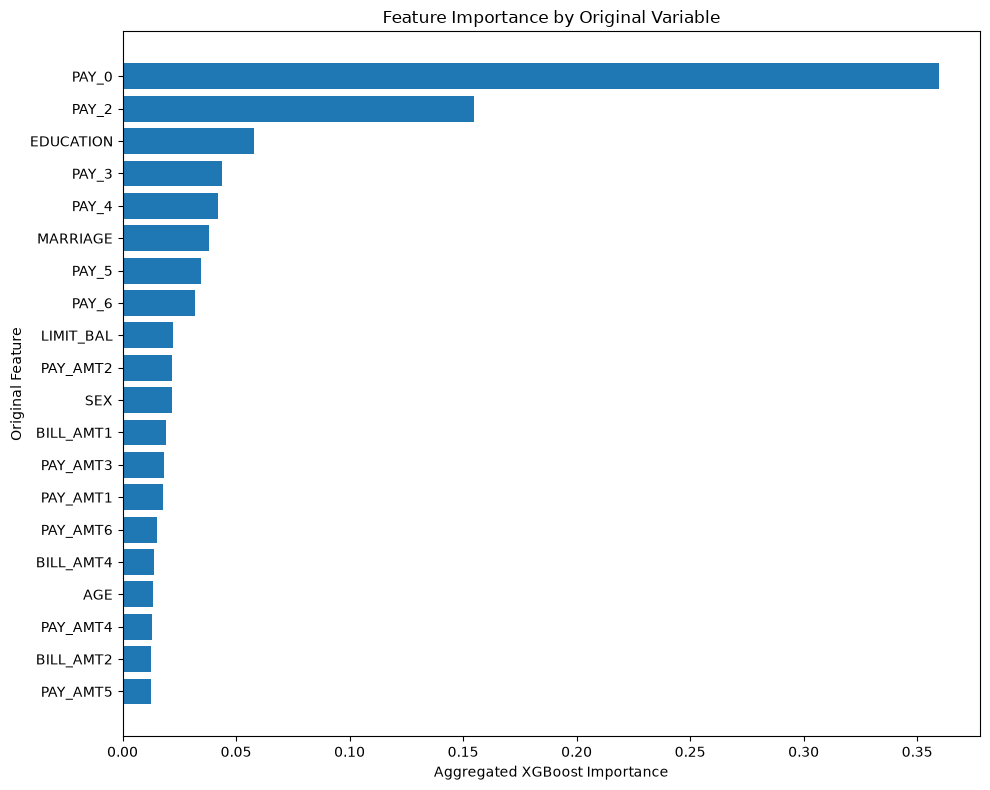

In [40]:
#### Plot original-feature importance
plot_df = (
    aggregated_importance_df
    .head(20)
    .sort_values("Importance")
)

plt.figure(figsize=(10, 8))

plt.barh(
    plot_df["Original Feature"],
    plot_df["Importance"]
)

plt.xlabel("Aggregated XGBoost Importance")
plt.ylabel("Original Feature")
plt.title("Feature Importance by Original Variable")

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "02_original_feature_importance.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Permutation importance

#### Test-set permutation importance

In [41]:
permutation_sample = X_test.copy()

if len(permutation_sample) > PERMUTATION_SAMPLE_SIZE:
    permutation_sample = permutation_sample.sample(
        n=PERMUTATION_SAMPLE_SIZE,
        random_state=RANDOM_STATE
    )

permutation_y = y_test.loc[
    permutation_sample.index
]

print(
    "Permutation sample:",
    permutation_sample.shape
)

Permutation sample: (2000, 23)


#### Calculate permutation importance

In [42]:
permutation_result = permutation_importance(
    final_base_model,
    permutation_sample,
    permutation_y,
    scoring="roc_auc",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

permutation_importance_df = pd.DataFrame({
    "Feature": permutation_sample.columns,
    "Importance Mean": permutation_result.importances_mean,
    "Importance Std": permutation_result.importances_std
})

permutation_importance_df = (
    permutation_importance_df
    .sort_values(
        "Importance Mean",
        ascending=False
    )
    .reset_index(drop=True)
)

display(permutation_importance_df)

,Feature,Importance Mean,Importance Std
0,PAY_0,0.073660,0.006757
1,LIMIT_BAL,0.025160,0.004562
2,BILL_AMT1,0.008098,0.003297
3,PAY_2,0.004352,0.002877
4,PAY_4,0.003559,0.002166
5,PAY_AMT2,0.003243,0.002569
6,PAY_3,0.003224,0.002581
7,BILL_AMT3,0.002645,0.001372
8,BILL_AMT4,0.002447,0.001016
9,PAY_AMT6,0.002246,0.001407


#### Plot permutation importance

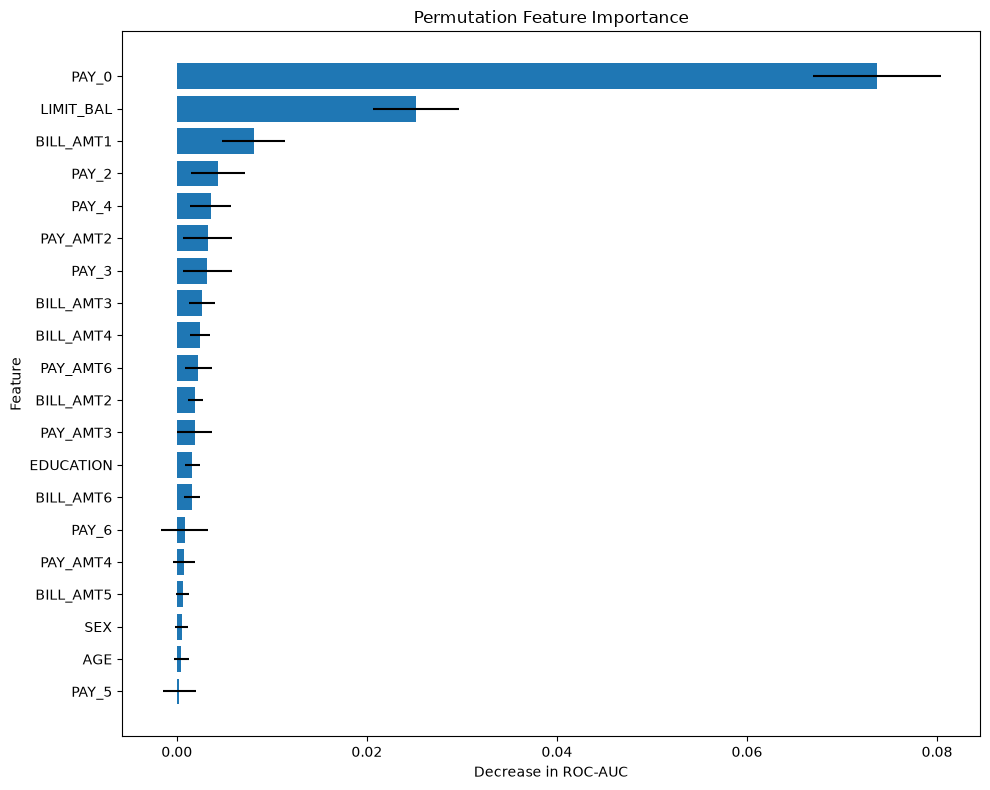

In [43]:
plot_df = (
    permutation_importance_df
    .head(20)
    .sort_values("Importance Mean")
)

plt.figure(figsize=(10, 8))

plt.barh(
    plot_df["Feature"],
    plot_df["Importance Mean"],
    xerr=plot_df["Importance Std"]
)

plt.xlabel("Decrease in ROC-AUC")
plt.ylabel("Feature")
plt.title("Permutation Feature Importance")

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "03_permutation_importance.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### SHAP analysis

#### Prepare transformed test sample

In [44]:
X_shap = X_test.copy()

if len(X_shap) > SHAP_SAMPLE_SIZE:
    X_shap = X_shap.sample(
        n=SHAP_SAMPLE_SIZE,
        random_state=RANDOM_STATE
    )

y_shap = y_test.loc[X_shap.index]

X_shap_transformed = fitted_preprocessor.transform(
    X_shap
)

X_shap_transformed = np.asarray(
    X_shap_transformed
)

print("SHAP observations:", X_shap.shape)
print(
    "Transformed SHAP shape:",
    X_shap_transformed.shape
)

SHAP observations: (1000, 23)
Transformed SHAP shape: (1000, 33)


#### Create SHAP explainer

In [45]:
explainer = shap.TreeExplainer(
    fitted_xgb
)

shap_values = explainer.shap_values(
    X_shap_transformed
)

print(
    "SHAP values shape:",
    np.asarray(shap_values).shape
)

SHAP values shape: (1000, 33)


#### SHAP summary bar plot

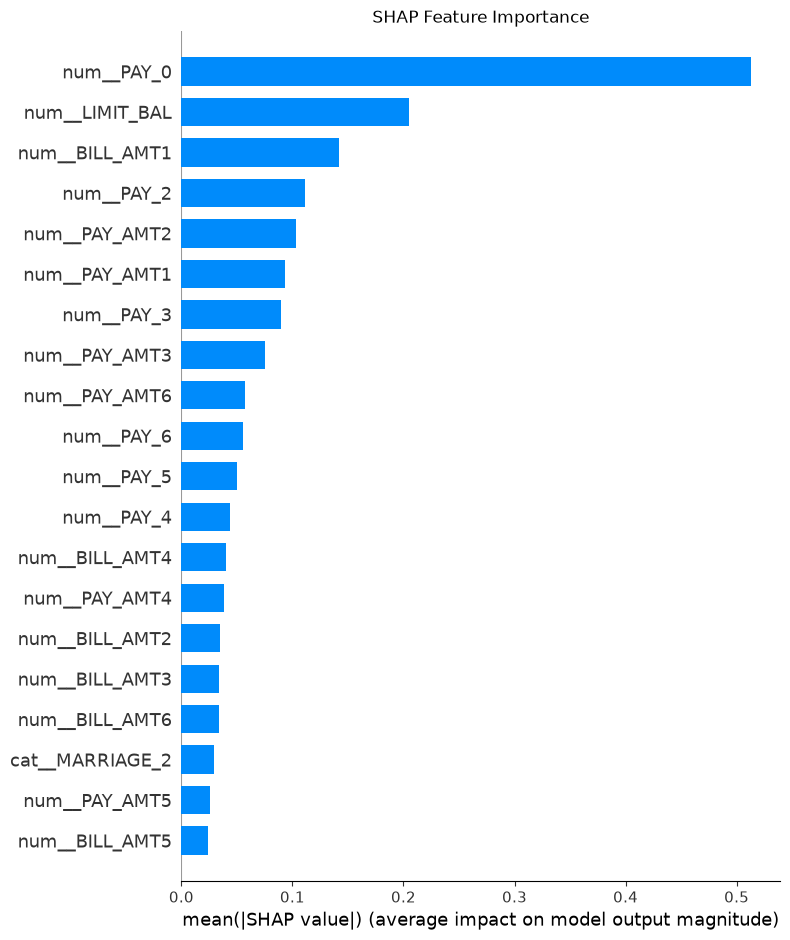

In [46]:
plt.figure()

shap.summary_plot(
    shap_values,
    X_shap_transformed,
    feature_names=transformed_feature_names,
    plot_type="bar",
    show=False
)

plt.title("SHAP Feature Importance")

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "04_shap_feature_importance.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### SHAP beeswarm plot

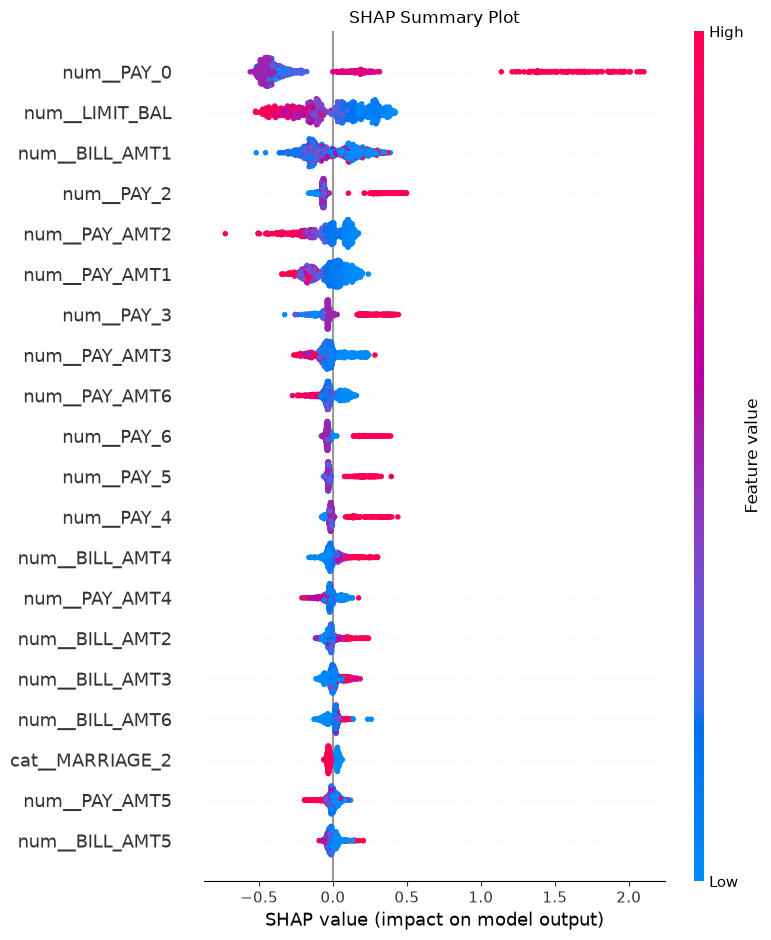

In [47]:
plt.figure()

shap.summary_plot(
    shap_values,
    X_shap_transformed,
    feature_names=transformed_feature_names,
    show=False
)

plt.title("SHAP Summary Plot")

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "05_shap_summary.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Aggregate SHAP values to original variables

#### Calculate original-feature SHAP importance

In [48]:
shap_abs_mean = np.abs(shap_values).mean(axis=0)

shap_transformed_df = pd.DataFrame({
    "Transformed Feature": transformed_feature_names,
    "Mean Absolute SHAP": shap_abs_mean
})

shap_transformed_df["Original Feature"] = (
    shap_transformed_df["Transformed Feature"]
    .apply(get_original_feature)
)

shap_original_df = (
    shap_transformed_df
    .groupby("Original Feature", as_index=False)[
        "Mean Absolute SHAP"
    ]
    .sum()
    .sort_values(
        "Mean Absolute SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

display(shap_original_df)

,Original Feature,Mean Absolute SHAP
0,PAY_0,0.513383
1,LIMIT_BAL,0.204634
2,BILL_AMT1,0.141599
3,PAY_2,0.111160
4,PAY_AMT2,0.103172
5,PAY_AMT1,0.093487
6,PAY_3,0.089967
7,PAY_AMT3,0.075334
8,PAY_AMT6,0.057464
9,PAY_6,0.055402


#### Plot original-feature SHAP importance

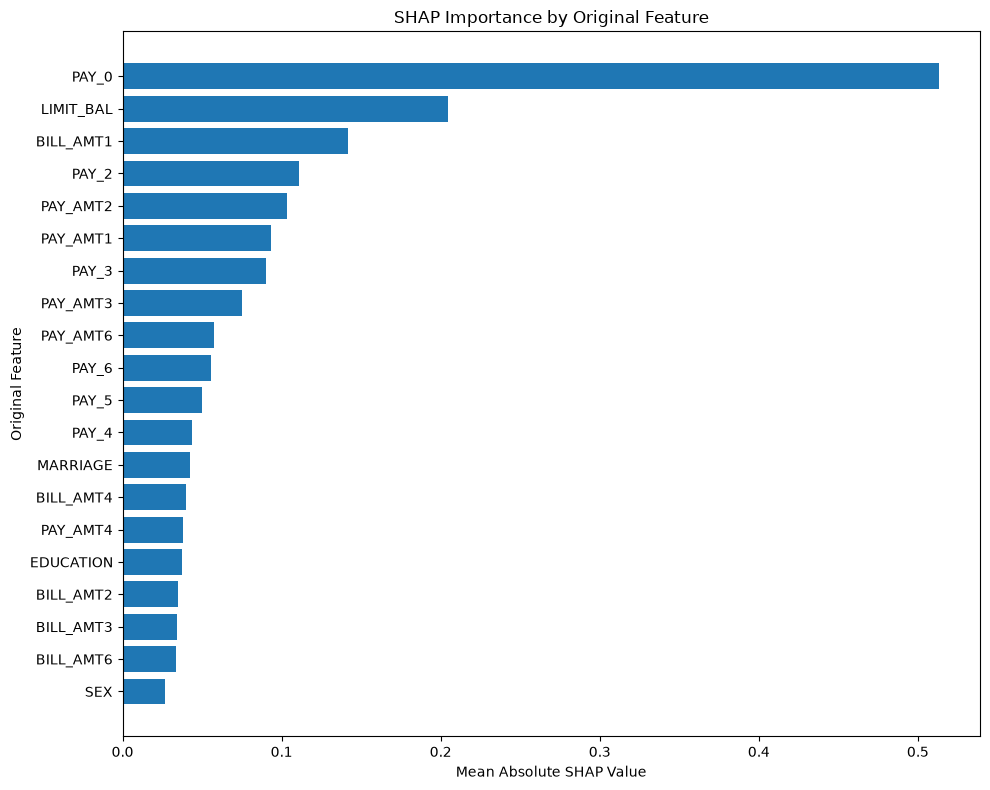

In [49]:
plot_df = (
    shap_original_df
    .head(20)
    .sort_values("Mean Absolute SHAP")
)

plt.figure(figsize=(10, 8))

plt.barh(
    plot_df["Original Feature"],
    plot_df["Mean Absolute SHAP"]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Original Feature")
plt.title("SHAP Importance by Original Feature")

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "06_shap_original_features.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### SHAP dependence plots

#### Identify top SHAP features

In [50]:
top_shap_features = (
    shap_original_df
    .head(10)["Original Feature"]
    .tolist()
)

print("Top SHAP features:")
for i, feature in enumerate(
    top_shap_features,
    start=1
):
    print(f"{i}. {feature}")

Top SHAP features:
1. PAY_0
2. LIMIT_BAL
3. BILL_AMT1
4. PAY_2
5. PAY_AMT2
6. PAY_AMT1
7. PAY_3
8. PAY_AMT3
9. PAY_AMT6
10. PAY_6


#### SHAP dependence plots for top features

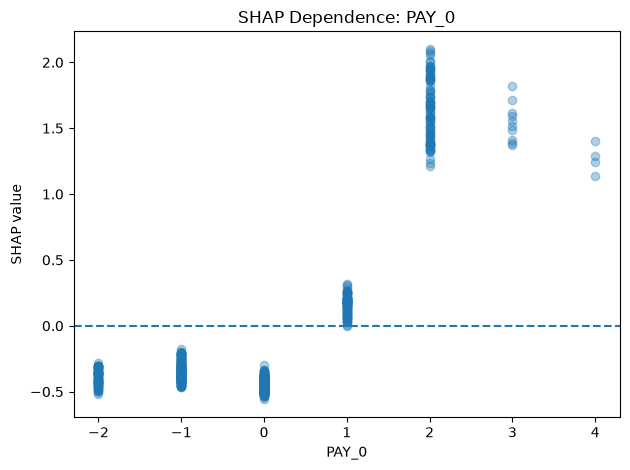

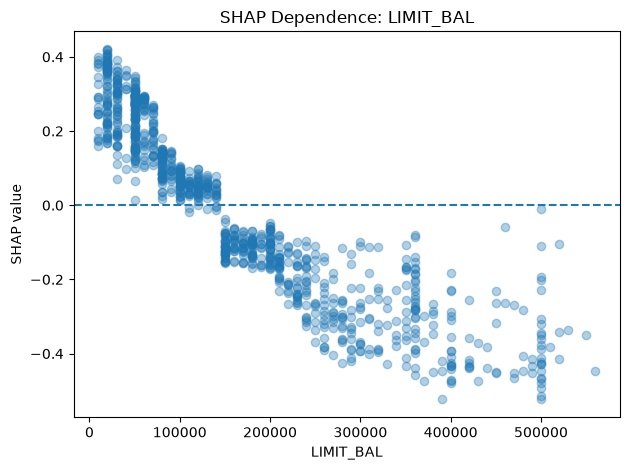

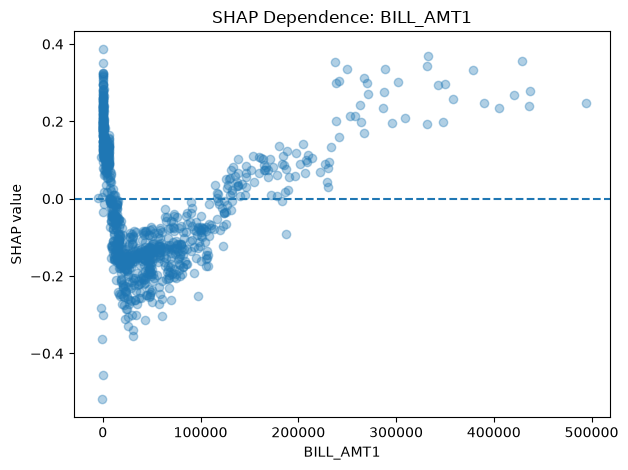

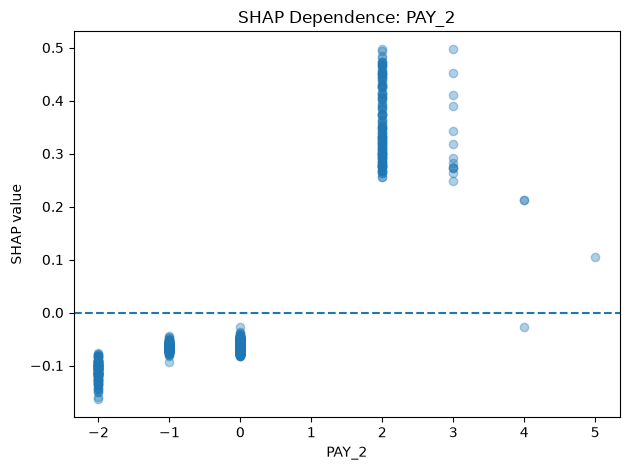

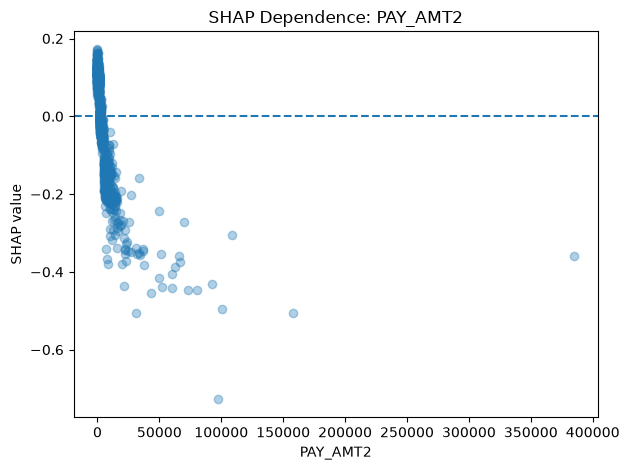

In [51]:
for feature in top_shap_features[:5]:

    if feature not in X_shap.columns:
        continue

    plt.figure()

    shap_feature_index = list(
        X_shap.columns
    ).index(feature)

    shap_original_feature_values = (
        X_shap[feature].values
    )

    feature_shap_values = shap_values[
        :,
        [
            i for i, name in enumerate(
                transformed_feature_names
            )
            if get_original_feature(name) == feature
        ]
    ].sum(axis=1)

    plt.scatter(
        shap_original_feature_values,
        feature_shap_values,
        alpha=0.35
    )

    plt.axhline(
        0,
        linestyle="--"
    )

    plt.xlabel(feature)
    plt.ylabel("SHAP value")
    plt.title(
        f"SHAP Dependence: {feature}"
    )

    plt.tight_layout()

    safe_name = (
        feature
        .replace("/", "_")
        .replace(" ", "_")
    )

    plt.savefig(
        os.path.join(
            OUTPUT_DIR,
            f"07_shap_dependence_{safe_name}.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

### Individual customer explanation

#### Select one test observation

In [52]:
observation_position = 0

observation_index = X_shap.index[
    observation_position
]

observation = X_shap.loc[
    [observation_index]
]

observation_target = y_shap.loc[
    observation_index
]

observation_probability = final_base_model.predict_proba(
    observation
)[0, 1]

print("Observation index:", observation_index)
print("Actual outcome:", observation_target)
print(
    "Predicted default probability:",
    observation_probability
)

display(observation)

Observation index: 20639
Actual outcome: 1
Predicted default probability: 0.42891762


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
20639,260000,1,1,1,37,0,0,3,2,2,2,163553,192724,188441,191134,193673,197104,32000,0,7100,7000,6500,7000


#### SHAP waterfall explanation

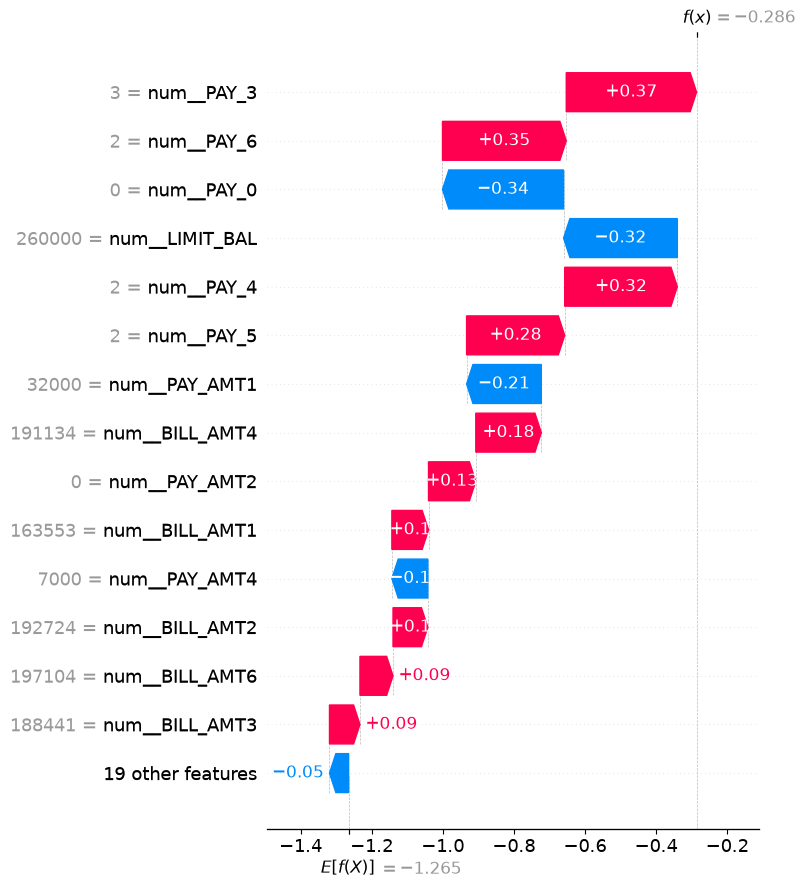

In [53]:
observation_transformed = fitted_preprocessor.transform(
    observation
)

observation_transformed = np.asarray(
    observation_transformed
)

observation_shap = explainer.shap_values(
    observation_transformed
)[0]

base_value = explainer.expected_value

if isinstance(base_value, np.ndarray):
    base_value = base_value.item()

waterfall_explanation = shap.Explanation(
    values=observation_shap,
    base_values=base_value,
    data=observation_transformed[0],
    feature_names=transformed_feature_names
)

plt.figure()

shap.plots.waterfall(
    waterfall_explanation,
    max_display=15,
    show=False
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "08_shap_individual_waterfall.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Compare the importance methods

#### Combine feature importance results

In [54]:
native_original = aggregated_importance_df.rename(
    columns={
        "Importance": "XGBoost Importance"
    }
)

permutation_original = permutation_importance_df.rename(
    columns={
        "Feature": "Original Feature",
        "Importance Mean": "Permutation Importance",
        "Importance Std": "Permutation Std"
    }
)

combined_importance_df = (
    native_original[
        [
            "Original Feature",
            "XGBoost Importance"
        ]
    ]
    .merge(
        permutation_original[
            [
                "Original Feature",
                "Permutation Importance",
                "Permutation Std"
            ]
        ],
        on="Original Feature",
        how="outer"
    )
    .merge(
        shap_original_df.rename(
            columns={
                "Mean Absolute SHAP":
                    "Mean Absolute SHAP"
            }
        ),
        on="Original Feature",
        how="outer"
    )
)

combined_importance_df = (
    combined_importance_df
    .sort_values(
        "Mean Absolute SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

display(combined_importance_df)

,Original Feature,XGBoost Importance,Permutation Importance,Permutation Std,Mean Absolute SHAP
0,PAY_0,0.359685,0.073660,0.006757,0.513383
1,LIMIT_BAL,0.022116,0.025160,0.004562,0.204634
2,BILL_AMT1,0.019356,0.008098,0.003297,0.141599
3,PAY_2,0.154992,0.004352,0.002877,0.111160
4,PAY_AMT2,0.021945,0.003243,0.002569,0.103172
5,PAY_AMT1,0.017907,-0.000592,0.002110,0.093487
6,PAY_3,0.043724,0.003224,0.002581,0.089967
7,PAY_AMT3,0.018393,0.001895,0.001841,0.075334
8,PAY_AMT6,0.015171,0.002246,0.001407,0.057464
9,PAY_6,0.031917,0.000826,0.002480,0.055402


#### Rank features

In [55]:
ranking_df = combined_importance_df.copy()

ranking_df["XGBoost Rank"] = (
    ranking_df["XGBoost Importance"]
    .rank(
        ascending=False,
        method="min"
    )
)

ranking_df["Permutation Rank"] = (
    ranking_df["Permutation Importance"]
    .rank(
        ascending=False,
        method="min"
    )
)

ranking_df["SHAP Rank"] = (
    ranking_df["Mean Absolute SHAP"]
    .rank(
        ascending=False,
        method="min"
    )
)

ranking_df["Average Rank"] = (
    ranking_df[
        [
            "XGBoost Rank",
            "Permutation Rank",
            "SHAP Rank"
        ]
    ]
    .mean(axis=1)
)

ranking_df = (
    ranking_df
    .sort_values("Average Rank")
    .reset_index(drop=True)
)

display(ranking_df)

,Original Feature,XGBoost Importance,Permutation Importance,Permutation Std,Mean Absolute SHAP,XGBoost Rank,Permutation Rank,SHAP Rank,Average Rank
0,PAY_0,0.359685,0.073660,0.006757,0.513383,1.0,1.0,1.0,1.000000
1,PAY_2,0.154992,0.004352,0.002877,0.111160,2.0,4.0,4.0,3.333333
2,LIMIT_BAL,0.022116,0.025160,0.004562,0.204634,9.0,2.0,2.0,4.333333
3,BILL_AMT1,0.019356,0.008098,0.003297,0.141599,12.0,3.0,3.0,6.000000
4,PAY_3,0.043724,0.003224,0.002581,0.089967,4.0,7.0,7.0,6.000000
5,PAY_AMT2,0.021945,0.003243,0.002569,0.103172,10.0,6.0,5.0,7.000000
6,PAY_4,0.042229,0.003559,0.002166,0.043767,5.0,5.0,12.0,7.333333
7,EDUCATION,0.058083,0.001632,0.000819,0.037160,3.0,13.0,16.0,10.666667
8,PAY_6,0.031917,0.000826,0.002480,0.055402,8.0,15.0,10.0,11.000000
9,PAY_AMT3,0.018393,0.001895,0.001841,0.075334,13.0,12.0,8.0,11.000000


### Save results

In [56]:
native_importance_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "xgboost_transformed_feature_importance.csv"
    ),
    index=False
)

aggregated_importance_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "xgboost_original_feature_importance.csv"
    ),
    index=False
)

permutation_importance_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "permutation_importance.csv"
    ),
    index=False
)

shap_transformed_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "shap_transformed_feature_importance.csv"
    ),
    index=False
)

shap_original_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "shap_original_feature_importance.csv"
    ),
    index=False
)

combined_importance_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "combined_feature_importance.csv"
    ),
    index=False
)

ranking_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "feature_importance_ranking.csv"
    ),
    index=False
)

print("CSV outputs saved.")

CSV outputs saved.


#### Save model

In [57]:
import joblib

model_output_path = os.path.join(
    OUTPUT_DIR,
    "final_xgboost_model.pkl"
)

joblib.dump(
    final_base_model,
    model_output_path
)

print(
    "Model saved to:",
    model_output_path
)

Model saved to: notebook8_outputs\final_xgboost_model.pkl


### Summary

In [58]:
print("=" * 75)
print("NOTEBOOK 8 - FINAL SUMMARY")
print("=" * 75)

print("\nDataset")
print("-" * 75)
print("Total observations:", len(df))
print("Total original features:", X.shape[1])

print("\nModel")
print("-" * 75)
print("Model: XGBoost")
print("Training observations:", len(X_model_train))
print("Calibration observations:", len(X_calibration))
print("Test observations:", len(X_test))

print("\nROC-AUC")
print("-" * 75)
print(
    f"Training:    {roc_auc_score(y_model_train, train_prob):.6f}"
)
print(
    f"Calibration: {roc_auc_score(y_calibration, calibration_prob):.6f}"
)
print(
    f"Test:        {roc_auc_score(y_test, test_prob):.6f}"
)

print("\nTop 10 features by SHAP")
print("-" * 75)

display(
    shap_original_df.head(10)
)

print("\nTop 10 features by permutation importance")
print("-" * 75)

display(
    permutation_importance_df.head(10)
)

print("\nOutputs")
print("-" * 75)

for filename in sorted(os.listdir(OUTPUT_DIR)):
    print(filename)

print("\nNotebook 8 completed.")

NOTEBOOK 8 - FINAL SUMMARY

Dataset
---------------------------------------------------------------------------
Total observations: 30000
Total original features: 23

Model
---------------------------------------------------------------------------
Model: XGBoost
Training observations: 19200
Calibration observations: 4800
Test observations: 6000

ROC-AUC
---------------------------------------------------------------------------
Training:    0.827626
Calibration: 0.780040
Test:        0.780532

Top 10 features by SHAP
---------------------------------------------------------------------------


,Original Feature,Mean Absolute SHAP
0,PAY_0,0.513383
1,LIMIT_BAL,0.204634
2,BILL_AMT1,0.141599
3,PAY_2,0.111160
4,PAY_AMT2,0.103172
5,PAY_AMT1,0.093487
6,PAY_3,0.089967
7,PAY_AMT3,0.075334
8,PAY_AMT6,0.057464
9,PAY_6,0.055402



Top 10 features by permutation importance
---------------------------------------------------------------------------


,Feature,Importance Mean,Importance Std
0,PAY_0,0.073660,0.006757
1,LIMIT_BAL,0.025160,0.004562
2,BILL_AMT1,0.008098,0.003297
3,PAY_2,0.004352,0.002877
4,PAY_4,0.003559,0.002166
5,PAY_AMT2,0.003243,0.002569
6,PAY_3,0.003224,0.002581
7,BILL_AMT3,0.002645,0.001372
8,BILL_AMT4,0.002447,0.001016
9,PAY_AMT6,0.002246,0.001407



Outputs
---------------------------------------------------------------------------
02_original_feature_importance.png
03_permutation_importance.png
04_shap_feature_importance.png
05_shap_summary.png
06_shap_original_features.png
07_shap_dependence_BILL_AMT1.png
07_shap_dependence_LIMIT_BAL.png
07_shap_dependence_PAY_0.png
07_shap_dependence_PAY_2.png
07_shap_dependence_PAY_AMT2.png
08_shap_individual_waterfall.png
combined_feature_importance.csv
feature_importance_ranking.csv
final_xgboost_model.pkl
permutation_importance.csv
shap_original_feature_importance.csv
shap_transformed_feature_importance.csv
xgboost_original_feature_importance.csv
xgboost_transformed_feature_importance.csv

Notebook 8 completed.


#### Final artifact saving

In [61]:
import os
import joblib

OUTPUT_DIR = globals().get("OUTPUT_DIR", ".")
ARTIFACT_DIR = os.path.join(OUTPUT_DIR, "final_artifacts")
os.makedirs(ARTIFACT_DIR, exist_ok=True)

candidates = {
    "final_base_model": "final_base_model",
    "X_model_train": "X_model_train",
    "y_model_train": "y_model_train",
    "X_calibration": "X_calibration",
    "y_calibration": "y_calibration",
    "X_test": "X_test",
    "y_test": "y_test",
    "train_prob": "train_prob",
    "calibration_prob": "calibration_prob",
    "test_prob": "test_prob",
    "final_test_results_df": "final_test_results_df",
    "test_calibration_error_df": "test_calibration_error_df",
    "shap_original_df": "shap_original_df",
    "permutation_importance_df": "permutation_importance_df"
}

saved_count = 0
print("--- Artifact Export Status ---")
for artifact_name, var_name in candidates.items():
    if var_name in globals():
        file_path = os.path.join(ARTIFACT_DIR, f"{artifact_name}.joblib")
        joblib.dump(globals()[var_name], file_path)
        print(f"[SAVED]   {artifact_name}.joblib")
        saved_count += 1
    else:
        print(f"[SKIPPED] {artifact_name} (variable '{var_name}' not defined in memory)")

print(f"\nSuccessfully saved {saved_count} artifacts to:")
print(os.path.abspath(ARTIFACT_DIR))

--- Artifact Export Status ---
[SAVED]   final_base_model.joblib
[SAVED]   X_model_train.joblib
[SAVED]   y_model_train.joblib
[SAVED]   X_calibration.joblib
[SAVED]   y_calibration.joblib
[SAVED]   X_test.joblib
[SAVED]   y_test.joblib
[SAVED]   train_prob.joblib
[SAVED]   calibration_prob.joblib
[SAVED]   test_prob.joblib
[SKIPPED] final_test_results_df (variable 'final_test_results_df' not defined in memory)
[SKIPPED] test_calibration_error_df (variable 'test_calibration_error_df' not defined in memory)
[SAVED]   shap_original_df.joblib
[SAVED]   permutation_importance_df.joblib

Successfully saved 12 artifacts to:
c:\Users\rayan\OneDrive\Desktop\Credit_Risk\Credit-Risk-Scoring-System\notebooks\notebook8_outputs\final_artifacts


In [62]:
print("=" * 75)
print("NOTEBOOK 8 ARTIFACT VERIFICATION")
print("=" * 75)

required_files = [
    "final_base_model.joblib",
    "X_model_train.joblib",
    "y_model_train.joblib",
    "X_calibration.joblib",
    "y_calibration.joblib",
    "X_test.joblib",
    "y_test.joblib",
    "train_prob.joblib",
    "calibration_prob.joblib",
    "test_prob.joblib"
]

missing = [
    f for f in required_files
    if not os.path.exists(os.path.join(ARTIFACT_DIR, f))
]

if missing:
    print("Missing artifacts:")
    for f in missing:
        print("-", f)
else:
    print("✓ All required Notebook 9 artifacts were saved.")

NOTEBOOK 8 ARTIFACT VERIFICATION
✓ All required Notebook 9 artifacts were saved.
